# Generic acceptance diagnostic

A small, interactive version of `slurm/generic_acceptance.jl`. It runs a PSR acceptance calculation, summarizes the trial outcomes, and plots detected counts and effective acceptance.

Use the **Julia (CoRaLS)** kernel described in the README. The default settings are intentionally small and are for a quick diagnostic rather than a production result.

In [1]:
using CoRaLS
using PyPlot
using Unitful: km, m, cm, sr, EeV, MHz, yr, ustrip
using CSV, DataFrames, Interpolations
using Random

# Reproducible trial sampling makes quick comparisons easier.
Random.seed!(20260917)

TaskLocalRNG()

## Run configuration

`ntrials` is per energy bin. Keep `max_tries = 1` and `min_count = 0` for a quick run; increase both (and `ntrials`) only when producing a physics result.

In [10]:
# Diagnostic-sized run: increase these for a production calculation.
ntrials = 10^7
nbins =10 

altitude = 50km
ice_depth = 5m
min_energy = 0.001EeV
max_energy = 100EeV

# Generic-acceptance geometry and LPDA trigger.
#region = PSRRegion()

#aoi = CoRaLS.SouthPoleAOI(-80.0)
#
#region = CustomAOIRegion(
#    make_psr_criteria(),      # retain the actual PSR-mask lookup
#    CoRaLS.aoi_area(aoi),     # normalize acceptance to the −87°–−90° cap
#    aoi,
#    1.0,
#)

region = create_region("polar:south,-87,1.0")

#spacecraft = FixedPlatform(-80.0, 0.0, altitude)
spacecraft = CircularOrbit(altitude)
trigger = LPDA(Nant=8, Ntrig=3, θ0=-48.0, altitude=altitude, skyfrac=0.15)

# The all-ones table is a convenient diagnostic attenuation model.
attenuation_table = CSV.read(joinpath(pkgdir(CoRaLS), "data", "allOnes.csv"), DataFrame)
satten = linear_interpolation(attenuation_table[:, 1], attenuation_table[:, 2])

nothing

## Calculate acceptance

This keeps only triggered events in `A.direct` and `A.reflected`, which is useful for the event-energy histogram below. No result file is written by default.

In [11]:
A = acceptance(
    ntrials, nbins;
    region=region,
    spacecraft=spacecraft,
    trigger=trigger,
    ice_depth=ice_depth,
    ice_thickness=1m,
    Nice=1.265,
    Nbed=regolith_index(LSB_DivinerIndex(), ice_depth),
    min_energy=min_energy,
    max_energy=max_energy,
    ν_min=150MHz,
    ν_max=800MHz,
    dν=10MHz,
    min_count=0,
    max_tries=1,
    simple_area=false,
    tand_mag=0.00025,
    tanδnorm=0.0005,
    slopemodel=GaussianSlope(7.6),
    roughnessmodel=GaussianRoughness(2.0),
    iceroughness=GaussianIceRoughness(2cm),
    low_temp_corr_factor=0.9,
    satten=satten,
    indexmodel=LSB_DivinerIndex(),
    densitymodel=LSB_Diviner_Density(),
    save_events=true,
    savetriggered=true,
)

[ Info: Calculating acceptance using 10000000 trials across 10 bins with up to 0 retries
Simulating... 100%|██████████████████████████████████████| Time: 0:07:32


CoRaLS.Acceptance([10000000, 10000000, 10000000, 10000000, 10000000, 10000000, 10000000, 10000000, 10000000, 10000000], PolarRegion
  aoi: CoRaLS.SouthPoleAOI
  aoi_frac: Float64 1.0
, CircularOrbit(50.0 km), Unitful.Quantity{Float64, 𝐋^2 𝐌 𝐓^-2, Unitful.FreeUnits{(EeV,), 𝐋^2 𝐌 𝐓^-2, nothing}}[0.001 EeV, 0.0031622776601683794 EeV, 0.010000000000000002 EeV, 0.03162277660168379 EeV, 0.1 EeV, 0.31622776601683794 EeV, 1.0 EeV, 3.1622776601683795 EeV, 10.0 EeV, 31.622776601683793 EeV, 100.0 EeV], 81657.74861966974 km^2 sr, Unitful.Quantity{Float64, 𝐋^2, Unitful.FreeUnits{(km^2, sr), 𝐋^2, nothing}}[0.0 km^2 sr, 0.0 km^2 sr, 0.0 km^2 sr, 0.0 km^2 sr, 0.0 km^2 sr, 0.0 km^2 sr, 0.0 km^2 sr, 0.7512512873009616 km^2 sr, 7.202213428254871 km^2 sr, 32.22214760532168 km^2 sr], Unitful.Quantity{Float64, 𝐋^2, Unitful.FreeUnits{(km^2, sr), 𝐋^2, nothing}}[0.0 km^2 sr, 0.0 km^2 sr, 0.0 km^2 sr, 0.0 km^2 sr, 0.0 km^2 sr, 0.0 km^2 sr, 0.0 km^2 sr, 49.29678284169462 km^2 sr, 281.9968690831675 km^2 sr, 682.3

## Per-bin summary

The effective areas below are acceptances, in km² sr. At a small trial count, zeros and large Monte Carlo uncertainty are expected.

In [12]:
energy_edges = ustrip.(A.energies ./ EeV)
direct_error = sqrt.(A.dcount ./ A.ntrials .* (1 .- A.dcount ./ A.ntrials) ./ A.ntrials) .* A.gAΩ
reflected_error = sqrt.(A.rcount ./ A.ntrials .* (1 .- A.rcount ./ A.ntrials) ./ A.ntrials) .* A.gAΩ

summary = DataFrame(
    energy_low_EeV=energy_edges[1:end-1],
    energy_high_EeV=energy_edges[2:end],
    trials=A.ntrials,
    direct_detected=A.dcount,
    reflected_detected=A.rcount,
    direct_acceptance_km2_sr=ustrip.(A.dAΩ ./ km^2 ./ sr),
    reflected_acceptance_km2_sr=ustrip.(A.rAΩ ./ km^2 ./ sr),
    direct_mcse_km2_sr=ustrip.(direct_error ./ km^2 ./ sr),
    reflected_mcse_km2_sr=ustrip.(reflected_error ./ km^2 ./ sr),
)

summary

Row,energy_low_EeV,energy_high_EeV,trials,direct_detected,reflected_detected,direct_acceptance_km2_sr,reflected_acceptance_km2_sr,direct_mcse_km2_sr,reflected_mcse_km2_sr
,Float64,Float64,Int64,Int64,Int64,Float64,Float64,Float64,Float64
1,0.001,0.00316228,10000000,0,0,0.0,0.0,0.0,0.0
2,0.00316228,0.01,10000000,0,0,0.0,0.0,0.0,0.0
3,0.01,0.0316228,10000000,0,0,0.0,0.0,0.0,0.0
4,0.0316228,0.1,10000000,0,0,0.0,0.0,0.0,0.0
5,0.1,0.316228,10000000,0,0,0.0,0.0,0.0,0.0
6,0.316228,1.0,10000000,0,0,0.0,0.0,0.0,0.0
7,1.0,3.16228,10000000,0,0,0.0,0.0,0.0,0.0
8,3.16228,10.0,10000000,92,6037,0.751251,49.2968,0.078323,0.634274
9,10.0,31.6228,10000000,882,34534,7.20221,281.997,0.2425,1.51485


## Detected-count histogram

This uses the simulation energy bins directly, so it remains meaningful even when few or no events trigger.

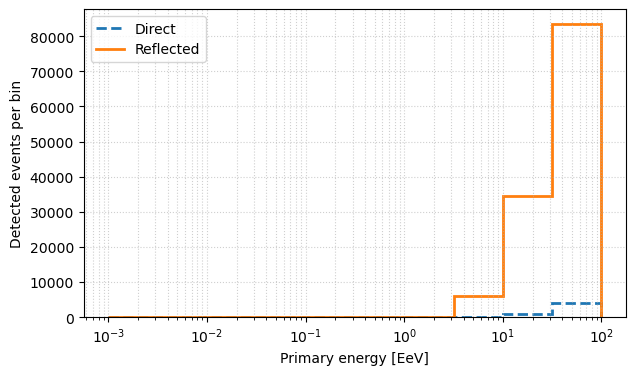

PyObject <matplotlib.legend.Legend object at 0x7486c430da50>

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.stairs(A.dcount, energy_edges, label="Direct", linestyle="--", linewidth=2)
ax.stairs(A.rcount, energy_edges, label="Reflected", linewidth=2)
ax.set_xscale("log")
ax.set(xlabel="Primary energy [EeV]", ylabel="Detected events per bin")
ax.grid(which="both", linestyle=":", alpha=0.6)
ax.legend()
#fig

## Effective acceptance and trial outcomes

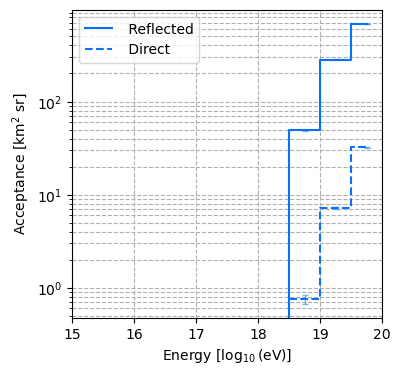

(Figure(PyObject <Figure size 400x400 with 1 Axes>), PyObject <Axes: xlabel='Energy [$\\log_{10}$(eV)]', ylabel='Acceptance [km$^2$ sr]'>)

In [14]:
# CoRaLS's acceptance plot includes binomial Monte Carlo error bars.
fig, ax = plot_acceptance(A; min_count=0)
#fig

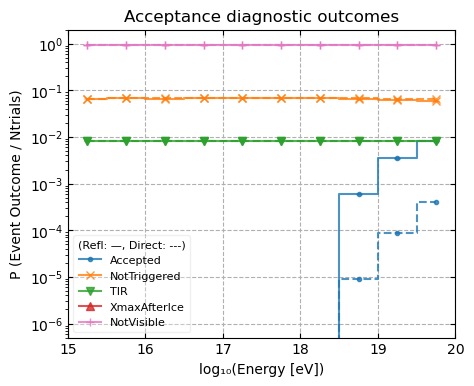

(Figure(PyObject <Figure size 500x400 with 1 Axes>), PyObject <Axes: title={'center': 'Acceptance diagnostic outcomes'}, xlabel='log₁₀(Energy [eV])', ylabel='P (Event Outcome / Ntrials)'>)

In [15]:
# Decompose each bin into accepted, not-triggered, and failed trials.
fig, ax = plot_event_outcomes(A; title="Acceptance diagnostic outcomes")
#fig

## Triggered-event energy histogram

This is populated only when the diagnostic run finds triggered events. Increase `ntrials` before treating its shape as physical.

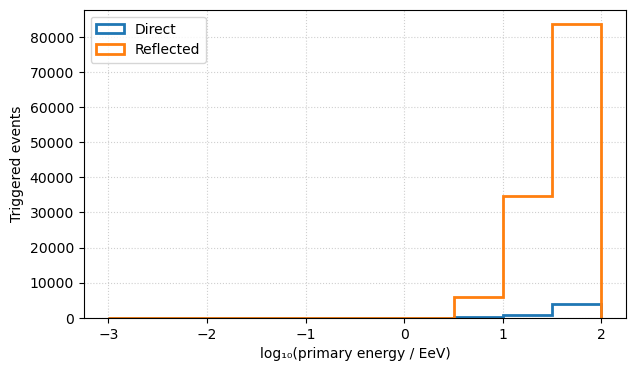

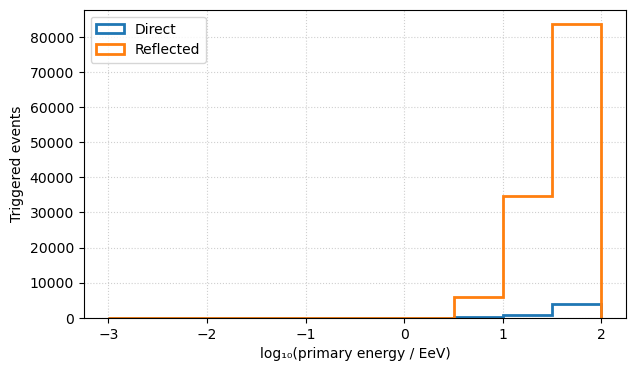

In [16]:
direct_energies = isempty(A.direct) ? Float64[] : ustrip.(A.direct.Ecr ./ EeV)
reflected_energies = isempty(A.reflected) ? Float64[] : ustrip.(A.reflected.Ecr ./ EeV)

fig, ax = plt.subplots(figsize=(7, 4))
if isempty(direct_energies) && isempty(reflected_energies)
    ax.text(0.5, 0.5, "No triggered events at this trial count", ha="center", va="center", transform=ax.transAxes)
else
    log_edges = range(log10(min_energy / EeV), log10(max_energy / EeV), length=nbins + 1)
    !isempty(direct_energies) && ax.hist(log10.(direct_energies), bins=log_edges, histtype="step", linewidth=2, label="Direct")
    !isempty(reflected_energies) && ax.hist(log10.(reflected_energies), bins=log_edges, histtype="step", linewidth=2, label="Reflected")
    ax.legend()
end
ax.set(xlabel="log₁₀(primary energy / EeV)", ylabel="Triggered events")
ax.grid(linestyle=":", alpha=0.6)
fig

## Optional rate estimate

This uses the same `differential_spectrum` calculation as `generic_acceptance.jl`, shown directly so the assumptions remain visible. Interpret low-count bins cautiously.

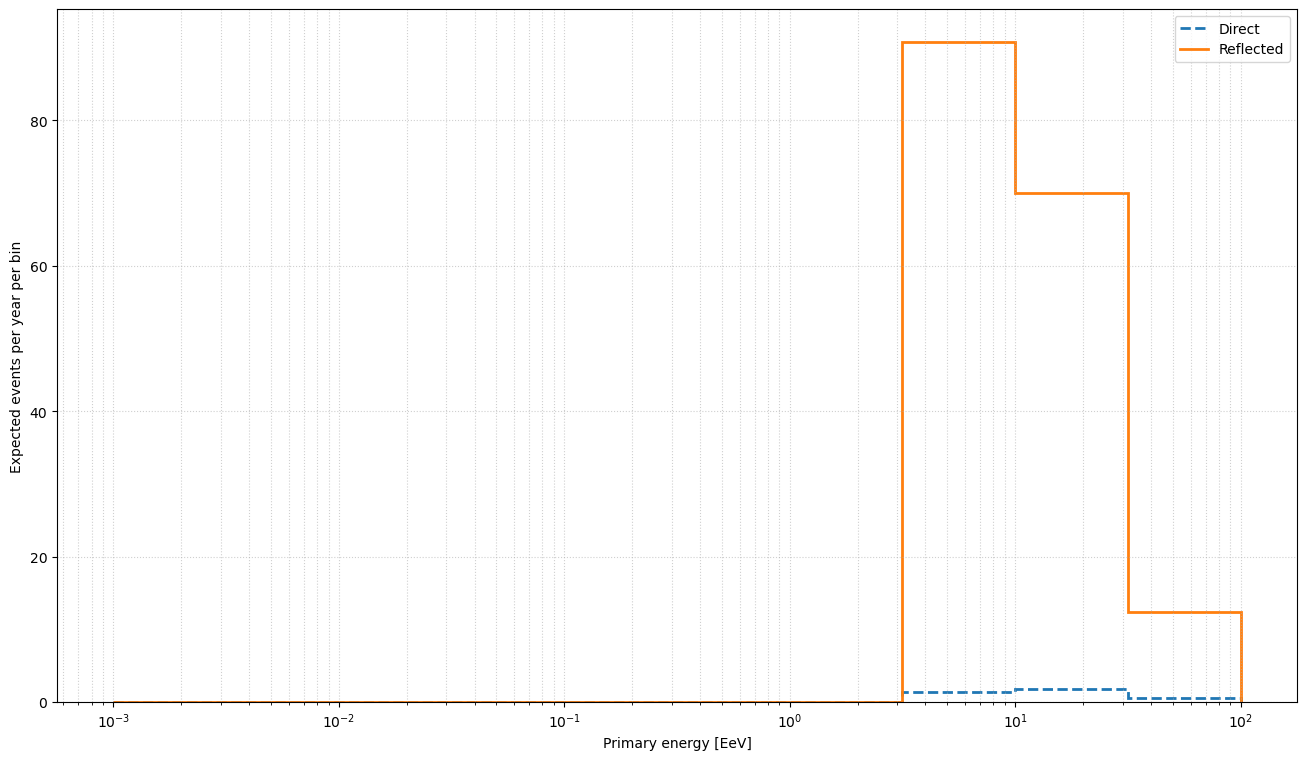

PyObject <matplotlib.legend.Legend object at 0x7486a8d231d0>

In [17]:
direct_rate = differential_spectrum(A.energies, A.dAΩ, 1yr)
reflected_rate = differential_spectrum(A.energies, A.rAΩ, 1yr)

fig, ax = plt.subplots(figsize=(16, 9))
ax.stairs(direct_rate, energy_edges, label="Direct", linestyle="--", linewidth=2)
ax.stairs(reflected_rate, energy_edges, label="Reflected", linewidth=2)
ax.set_xscale("log")
ax.set(xlabel="Primary energy [EeV]", ylabel="Expected events per year per bin")
ax.grid(which="both", linestyle=":", alpha=0.6)
ax.legend()

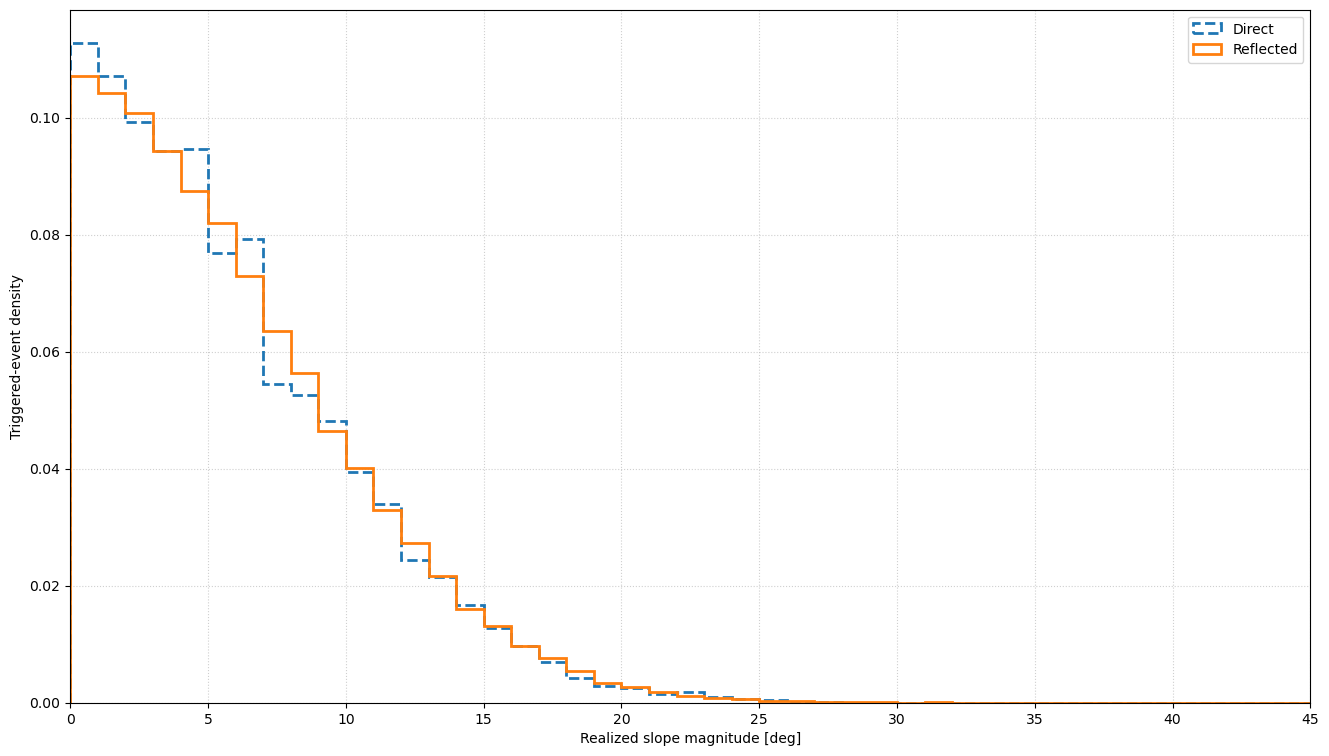

In [18]:
# A.direct and A.reflected contain triggered events because savetriggered=true.
direct_slopes = A.direct.slope_deg
reflected_slopes = A.reflected.slope_deg

fig, ax = plt.subplots(figsize=(16, 9))
slope_edges = 0.0:1.0:90.0
if isempty(direct_slopes) && isempty(reflected_slopes)
    ax.text(0.5, 0.5, "No triggered events at this trial count", ha="center", va="center", transform=ax.transAxes)
else
    !isempty(direct_slopes) && ax.hist(direct_slopes, bins=slope_edges, density=true, histtype="step", linewidth=2, linestyle="--", label="Direct")
    !isempty(reflected_slopes) && ax.hist(reflected_slopes, bins=slope_edges, density=true, histtype="step", linewidth=2, label="Reflected")
    ax.legend()
end
ax.set(xlabel="Realized slope magnitude [deg]", ylabel="Triggered-event density", xlim=(0, 45))
ax.grid(linestyle=":", alpha=0.6)
#fig